In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve, auc)
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SelectFromModel
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings('ignore')

#visualization style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams['font.size'] = 12


Dataset shape: (8000, 12)

Columns: ['user_id', 'gender', 'age', 'country', 'subscription_type', 'listening_time', 'songs_played_per_day', 'skip_rate', 'device_type', 'ads_listened_per_week', 'offline_listening', 'is_churned']

First 5 rows:


,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1




DATASET INFO - 
Total records: 8000
Total features: 12
Missing values: 0
Duplicate rows: 0

Data types:
user_id                    int64
gender                    object
age                        int64
country                   object
subscription_type         object
listening_time             int64
songs_played_per_day       int64
skip_rate                float64
device_type               object
ads_listened_per_week      int64
offline_listening          int64
is_churned                 int64
dtype: object

--------------------------------------------------
TARGET DISTRIBUTION (is_churned)
--------------------------------------------------
Class 0: 5929 samples (74.11%)
Class 1: 2071 samples (25.89%)


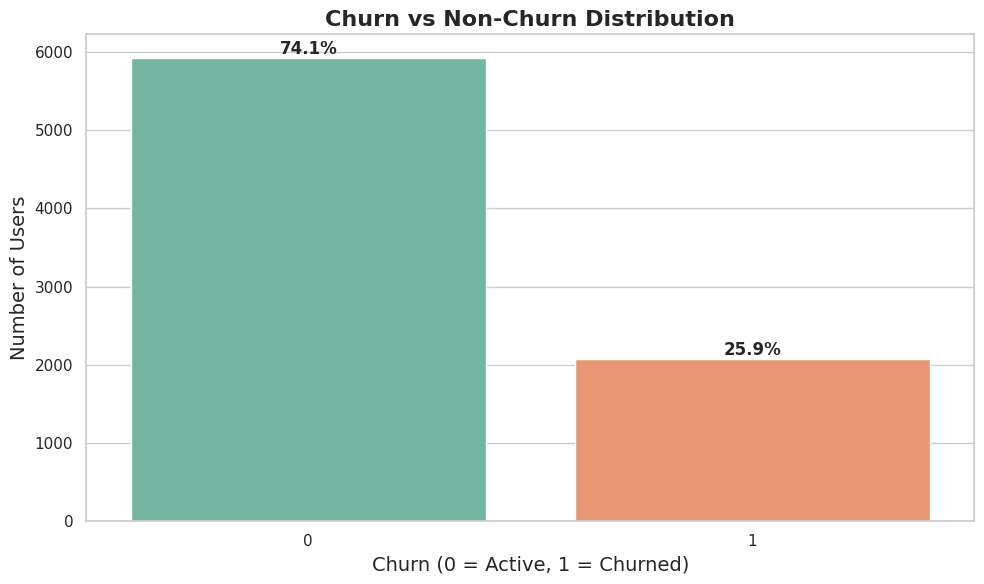

In [2]:
# Load dataset
df = pd.read_csv("spotify_churn_dataset.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
display(df.head())

# Dataset info
print("\n")
print("DATASET INFO - ")
print(f"Total records: {df.shape[0]}")
print(f"Total features: {df.shape[1]}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

# Data types
print("\nData types:")
print(df.dtypes)

# Target distribution
print("\n" + "-"*50)
print("TARGET DISTRIBUTION (is_churned)")
print("-"*50)
churn_dist = df['is_churned'].value_counts()
churn_percent = df['is_churned'].value_counts(normalize=True) * 100
for i, (count, percent) in enumerate(zip(churn_dist, churn_percent)):
    print(f"Class {i}: {count} samples ({percent:.2f}%)")

# churn distribution Visualization
plt.figure(figsize=(10, 6))
sns.countplot(x='is_churned', data=df, palette='Set2')
plt.title('Churn vs Non-Churn Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Churn (0 = Active, 1 = Churned)', fontsize=14)
plt.ylabel('Number of Users', fontsize=14)

# Add percentage labels
for i, p in enumerate(plt.gca().patches):
    plt.gca().annotate(f'{churn_percent[i]:.1f}%',
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [3]:
print("="*60)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*60)

# Statistical summary
print("\nNUMERICAL FEATURES STATISTICAL SUMMARY:")
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = [col for col in numerical_cols if col != 'user_id' and col != 'is_churned']
print(df[numerical_cols].describe().T)

# Categorical features analysis
print("\nCATEGORICAL FEATURES ANALYSIS:")
categorical_cols = ['gender', 'country', 'subscription_type', 'device_type']
for col in categorical_cols:
    print(f"\n{col}:")
    value_counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100
    for val, count, pct in zip(value_counts.index, value_counts.values, percentages.values):
        print(f"  {val}: {count} ({pct:.1f}%)")

# Correlation matrix for numerical features
print("\nCORRELATION MATRIX (Numerical Features):")
corr_matrix = df[numerical_cols + ['is_churned']].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Distribution of numerical features
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols[:9]):
    sns.histplot(data=df, x=col, hue='is_churned', kde=True, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'Distribution of {col} by Churn', fontsize=12)
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Count', fontsize=10)

plt.tight_layout()
plt.show()

# Churn rate by categorical features
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)['is_churned'].mean().sort_values()
    sns.barplot(x=churn_rate.index, y=churn_rate.values, ax=axes[idx], palette='viridis')
    axes[idx].set_title(f'Churn Rate by {col}', fontsize=14)
    axes[idx].set_xlabel(col, fontsize=12)
    axes[idx].set_ylabel('Churn Rate', fontsize=12)
    axes[idx].tick_params(axis='x', rotation=45)

    # Add value labels
    for i, v in enumerate(churn_rate.values):
        axes[idx].text(i, v + 0.01, f'{v:.2%}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Pairplot for key features
print("\nPAIRPLOT FOR KEY FEATURES:")
key_features = ['age', 'listening_time', 'songs_played_per_day', 'skip_rate', 'ads_listened_per_week']
key_features_df = df[key_features + ['is_churned']]

# Convert churn to string
key_features_df['is_churned_str'] = key_features_df['is_churned'].map({0: 'Active', 1: 'Churned'})

sns.pairplot(key_features_df, hue='is_churned_str', palette='Set2', diag_kind='kde',
             plot_kws={'alpha': 0.6, 's': 30}, diag_kws={'fill': True})
plt.suptitle('Pairplot of Key Features by Churn Status', y=1.02, fontsize=16, fontweight='bold')
plt.show()

#  Outliers check using boxplots
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols[:9]):
    sns.boxplot(data=df, x='is_churned', y=col, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{col} Distribution by Churn', fontsize=12)
    axes[idx].set_xlabel('Churn Status', fontsize=10)
    axes[idx].set_ylabel(col, fontsize=10)

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [4]:
print("="*50)
print("DATA PREPROCESSING")
print("="*50)

# Drop user_id as it's just an identifier
df = df.drop(columns=['user_id'])
print("✓ Dropped 'user_id' column")
print(f"New shape: {df.shape}")

# Check for outliers and handle them
print("\n OUTLIER DETECTION:")
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers)

for col in numerical_cols:
    outlier_count = detect_outliers_iqr(df, col)
    if outlier_count > 0:
        print(f"  {col}: {outlier_count} outliers detected ({outlier_count/len(df)*100:.1f}%)")

# Cap outliers instead of removing
print("\n✓ Capping outliers at 99th percentile...")
for col in numerical_cols:
    upper_limit = df[col].quantile(0.99)
    lower_limit = df[col].quantile(0.01)
    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])
    df[col] = np.where(df[col] < lower_limit, lower_limit, df[col])

# Feature Engineering
print("\n" + "-"*30)
print("FEATURE ENGINEERING")
print("-"*30)

# Create meaningful features
# Engagement Intensity (listening time per song)
df['avg_listening_per_song'] = df['listening_time'] / (df['songs_played_per_day'] + 1e-6)


# Engagement score (combination of multiple features)
df['engagement_score'] = (df['listening_time'] / df['listening_time'].max() +
                          df['songs_played_per_day'] / df['songs_played_per_day'].max() +
                          (1 - df['skip_rate'])) / 3


# Customer tenure proxy (based on age and listening patterns)
df['tenure_proxy'] = df['age'] * (df['listening_time'] / 100)


# Ad tolerance score
df['ad_tolerance'] = 1 - (df['ads_listened_per_week'] / (df['ads_listened_per_week'].max() + 1e-6))


# Device preference (encode as ordinal)
device_mapping = {'Mobile': 0, 'Desktop': 1, 'Web': 2}
df['device_preference'] = df['device_type'].map(device_mapping)


# Subscription value (ordinal encoding)
subscription_mapping = {'Free': 0, 'Student': 1, 'Family': 2, 'Premium': 3}
df['subscription_value'] = df['subscription_type'].map(subscription_mapping)


# Listening consistency (lower skip rate = more consistent)
df['listening_consistency'] = 1 - df['skip_rate']


# Age groups
df['age_group'] = pd.cut(df['age'],
                          bins=[0, 18, 25, 35, 50, 100],
                          labels=['Teen', 'Young Adult', 'Adult', 'Middle Age', 'Senior'])


# Listening intensity groups
df['listening_intensity'] = pd.qcut(df['listening_time'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])


print(f"\nTotal features after engineering: {df.shape[1]}")
print(f"Feature names: {df.columns.tolist()}")

# Display correlation of new features with target
new_features = ['avg_listening_per_song', 'engagement_score', 'tenure_proxy',
                'ad_tolerance', 'device_preference', 'subscription_value',
                'listening_consistency']

print("\n CORRELATION OF NEW FEATURES WITH TARGET:")
for feature in new_features:
    if feature in df.columns:
        corr = df[feature].corr(df['is_churned'])
        print(f"  {feature}: {corr:.3f}")

DATA PREPROCESSING
✓ Dropped 'user_id' column
New shape: (8000, 11)

 OUTLIER DETECTION:
  ads_listened_per_week: 1683 outliers detected (21.0%)

✓ Capping outliers at 99th percentile...

------------------------------
FEATURE ENGINEERING
------------------------------

Total features after engineering: 20
Feature names: ['gender', 'age', 'country', 'subscription_type', 'listening_time', 'songs_played_per_day', 'skip_rate', 'device_type', 'ads_listened_per_week', 'offline_listening', 'is_churned', 'avg_listening_per_song', 'engagement_score', 'tenure_proxy', 'ad_tolerance', 'device_preference', 'subscription_value', 'listening_consistency', 'age_group', 'listening_intensity']

 CORRELATION OF NEW FEATURES WITH TARGET:
  avg_listening_per_song: -0.003
  engagement_score: -0.005
  tenure_proxy: -0.010
  ad_tolerance: 0.002
  device_preference: -0.017
  subscription_value: 0.004
  listening_consistency: -0.016


PREPARING FEATURES & TARGET
Target variable: is_churned
Features shape: (8000, 19)
Target shape: (8000,)

✓ Numerical features: 13
✓ Categorical features: 4
✓ Additional features: 2
✓ Total features defined: 19
✓ Actual features in X: 19

Categorical feature unique values:
  gender: 3 values - ['Female', 'Other', 'Male']
  country: 8 values - ['CA', 'DE', 'AU', 'US', 'UK']...
  age_group: 5 values - ['Senior', 'Adult', 'Middle Age', 'Young Adult', 'Teen']
  listening_intensity: 4 values - ['Low', 'Medium', 'High', 'Very High']

TOP 15 FEATURES BY CORRELATION WITH TARGET:


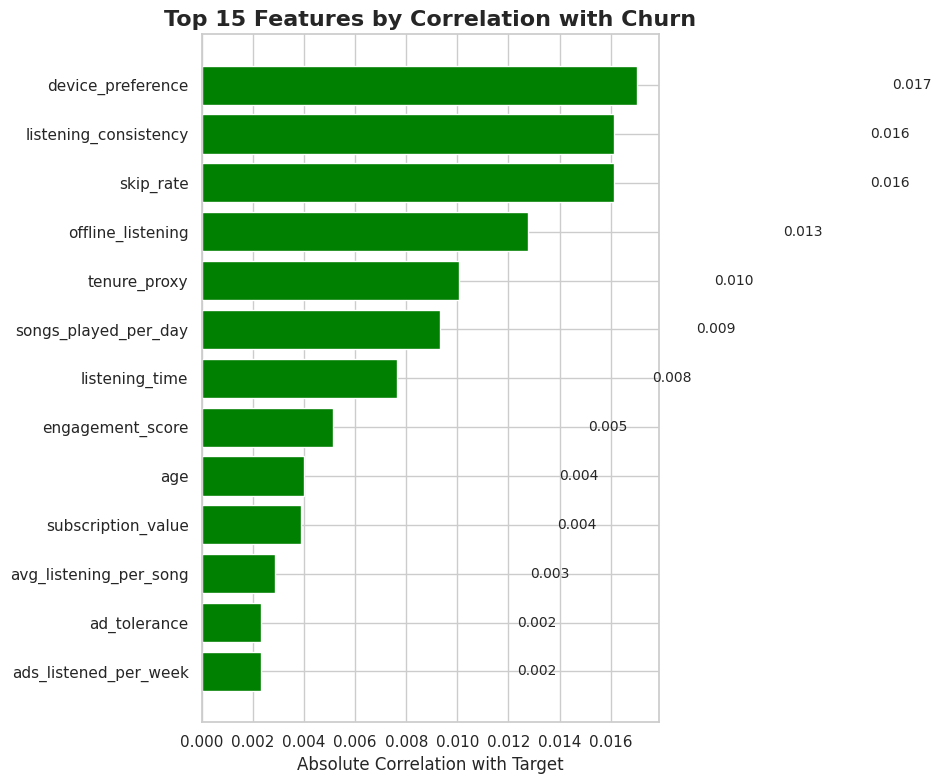

In [5]:
print("="*50)
print("PREPARING FEATURES & TARGET")
print("="*50)

# Define target variable
target = 'is_churned'
y = df[target]
X = df.drop(columns=[target])

print(f"Target variable: {target}")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Define feature categories
numerical_features = ['age', 'listening_time', 'songs_played_per_day',
                      'skip_rate', 'ads_listened_per_week', 'offline_listening',
                      'avg_listening_per_song', 'engagement_score',
                      'tenure_proxy', 'ad_tolerance', 'device_preference',
                      'subscription_value', 'listening_consistency']

# One-hot encode age_group and listening_intensity
categorical_features = ['gender', 'country', 'age_group', 'listening_intensity']

# Keep device_type and subscription_type for potential analysis
X['device_type'] = df['device_type']
X['subscription_type'] = df['subscription_type']

# Verify all columns are accounted for
all_features = numerical_features + categorical_features + ['device_type', 'subscription_type']
print(f"\n✓ Numerical features: {len(numerical_features)}")
print(f"✓ Categorical features: {len(categorical_features)}")
print(f"✓ Additional features: 2")
print(f"✓ Total features defined: {len(all_features)}")
print(f"✓ Actual features in X: {X.shape[1]}")

# Check unique values in categorical features
print("\nCategorical feature unique values:")
for col in categorical_features:
    unique_vals = X[col].unique()
    print(f"  {col}: {len(unique_vals)} values - {list(unique_vals)[:5]}{'...' if len(unique_vals) > 5 else ''}")

# Visualize feature importance using simple correlation
print("\nTOP 15 FEATURES BY CORRELATION WITH TARGET:")
feature_correlations = {}
for col in X.select_dtypes(include=['int64', 'float64']).columns:
    if col != 'is_churned':
        corr = X[col].corr(y)
        feature_correlations[col] = abs(corr)

# Sort by absolute correlation
sorted_features = sorted(feature_correlations.items(), key=lambda x: x[1], reverse=True)[:15]

plt.figure(figsize=(12, 8))
features, correlations = zip(*sorted_features)
colors = ['red' if corr < 0 else 'green' for corr in correlations]
bars = plt.barh(features, correlations, color=colors)
plt.xlabel('Absolute Correlation with Target', fontsize=12)
plt.title('Top 15 Features by Correlation with Churn', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()

# Add correlation values
for bar, corr in zip(bars, correlations):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{corr:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

TRAIN-TEST SPLIT
Training set: 6400 samples (80.0%)
Test set: 1600 samples (20.0%)

Train churn rate: 25.89%
Test churn rate: 25.87%
Overall churn rate: 25.89%


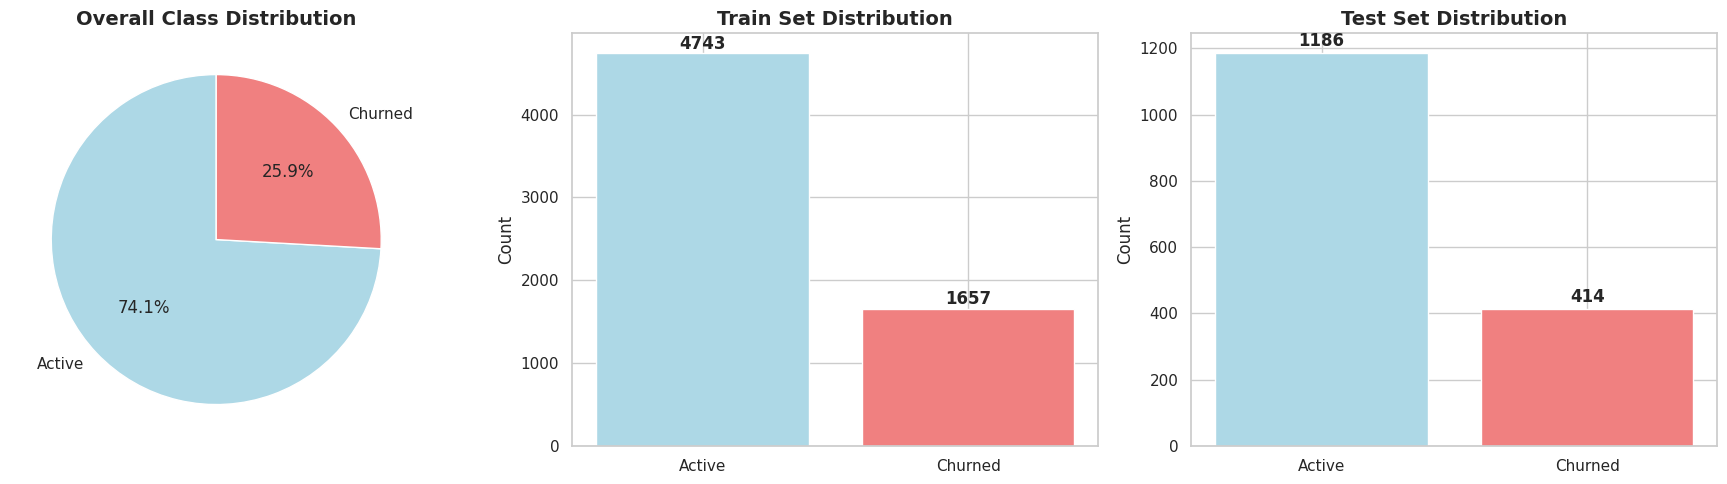

In [6]:
print("="*50)
print("TRAIN-TEST SPLIT")
print("="*50)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X):.1%})")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X):.1%})")
print(f"\nTrain churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")
print(f"Overall churn rate: {y.mean():.2%}")

# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall distribution
axes[0].pie([len(y[y==0]), len(y[y==1])],
           labels=['Active', 'Churned'],
           autopct='%1.1f%%',
           colors=['lightblue', 'lightcoral'],
           startangle=90)
axes[0].set_title('Overall Class Distribution', fontsize=14, fontweight='bold')

# Train distribution
train_counts = y_train.value_counts()
axes[1].bar(['Active', 'Churned'], train_counts.values, color=['lightblue', 'lightcoral'])
axes[1].set_title('Train Set Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(train_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Test distribution
test_counts = y_test.value_counts()
axes[2].bar(['Active', 'Churned'], test_counts.values, color=['lightblue', 'lightcoral'])
axes[2].set_title('Test Set Distribution', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Count')
for i, v in enumerate(test_counts.values):
    axes[2].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [7]:
print("="*50)
print("CREATING PREPROCESSING PIPELINE")
print("="*50)

# Create preprocessing transformers
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)


print(f" Numerical features: {len(numerical_features)}")
print(f" Categorical features: {len(categorical_features)}")

# Fit and transform training data
preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after encoding
num_feature_names = numerical_features
cat_encoder = preprocessor.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)

# Get remainder feature names
remainder_features = ['device_type', 'subscription_type']

all_feature_names = list(num_feature_names) + list(cat_feature_names) + remainder_features

print(f" Total features after encoding: {len(all_feature_names)}")
print(f" Training set shape after preprocessing: {X_train_processed.shape}")
print(f" Test set shape after preprocessing: {X_test_processed.shape}")

# Convert to DataFrames for easier handling
X_train_df = pd.DataFrame(X_train_processed, columns=all_feature_names)
X_test_df = pd.DataFrame(X_test_processed, columns=all_feature_names)


if 'device_type' in X_train_df.columns:
    X_train_df = X_train_df.drop(columns=['device_type'])
    X_test_df = X_test_df.drop(columns=['device_type'])
    all_feature_names.remove('device_type')
if 'subscription_type' in X_train_df.columns:
    X_train_df = X_train_df.drop(columns=['subscription_type'])
    X_test_df = X_test_df.drop(columns=['subscription_type'])
    all_feature_names.remove('subscription_type')

print(f"\n Converted to DataFrames")
print(f"Training DataFrame shape: {X_train_df.shape}")
print(f"Test DataFrame shape: {X_test_df.shape}")

CREATING PREPROCESSING PIPELINE
 Numerical features: 13
 Categorical features: 4
 Total features after encoding: 31
 Training set shape after preprocessing: (6400, 31)
 Test set shape after preprocessing: (1600, 31)

 Converted to DataFrames
Training DataFrame shape: (6400, 29)
Test DataFrame shape: (1600, 29)


HANDLING CLASS IMBALANCE

Original class distribution in training set:
is_churned
0    4743
1    1657
Name: count, dtype: int64
Churn rate: 25.89%

 STRATEGY 1: Applying SMOTE for oversampling...
After SMOTE - Training set shape: (9486, 29)
After SMOTE - Class distribution:
is_churned
0    4743
1    4743
Name: count, dtype: int64

STRATEGY 2: Applying SMOTE + RandomUnderSampler...
After balancing - Training set shape: (5334, 29)
After balancing - Class distribution:
is_churned
0    2963
1    2371
Name: count, dtype: int64


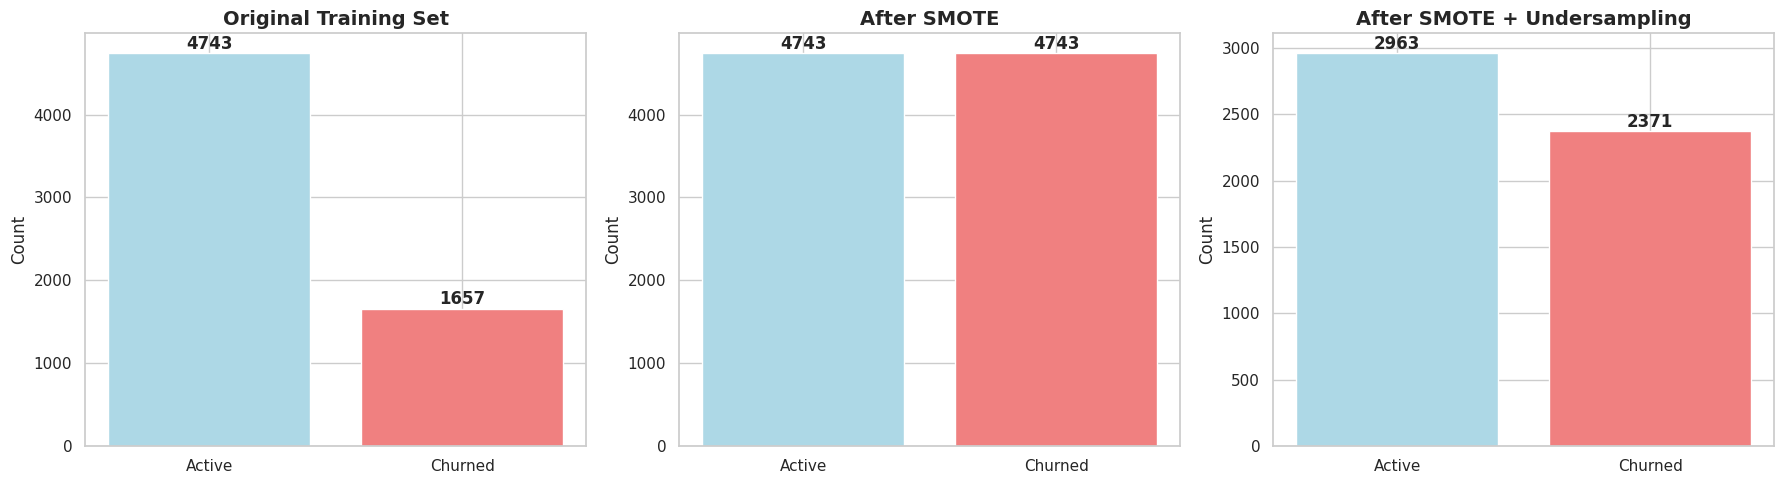


 Using SMOTE + Undersampling strategy for balanced training data.


In [8]:
print("="*50)
print("HANDLING CLASS IMBALANCE")
print("="*50)

# Check class imbalance
print(f"\nOriginal class distribution in training set:")
print(y_train.value_counts())
print(f"Churn rate: {y_train.mean():.2%}")

# SMOTE for oversampling
print("\n STRATEGY 1: Applying SMOTE for oversampling...")
smote = SMOTE(random_state=42, sampling_strategy='auto')
X_train_smote, y_train_smote = smote.fit_resample(X_train_df, y_train)

print(f"After SMOTE - Training set shape: {X_train_smote.shape}")
print(f"After SMOTE - Class distribution:")
print(pd.Series(y_train_smote).value_counts())

# combination of oversampling and undersampling
print("\nSTRATEGY 2: Applying SMOTE + RandomUnderSampler...")
over = SMOTE(sampling_strategy=0.5, random_state=42)
under = RandomUnderSampler(sampling_strategy=0.8, random_state=42)

# Create pipeline
pipeline = ImbPipeline([
    ('over', over),
    ('under', under)
])

X_train_balanced, y_train_balanced = pipeline.fit_resample(X_train_df, y_train)

print(f"After balancing - Training set shape: {X_train_balanced.shape}")
print(f"After balancing - Class distribution:")
print(pd.Series(y_train_balanced).value_counts())

# Visualize different strategies
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original
original_counts = y_train.value_counts()
axes[0].bar(['Active', 'Churned'], original_counts.values, color=['lightblue', 'lightcoral'])
axes[0].set_title('Original Training Set', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(original_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# SMOTE
smote_counts = pd.Series(y_train_smote).value_counts()
axes[1].bar(['Active', 'Churned'], smote_counts.values, color=['lightblue', 'lightcoral'])
axes[1].set_title('After SMOTE', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(smote_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Balanced
balanced_counts = pd.Series(y_train_balanced).value_counts()
axes[2].bar(['Active', 'Churned'], balanced_counts.values, color=['lightblue', 'lightcoral'])
axes[2].set_title('After SMOTE + Undersampling', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Count')
for i, v in enumerate(balanced_counts.values):
    axes[2].text(i, v + 30, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Balanced strategy (SMOTE + Undersampling)
X_train_final = X_train_balanced
y_train_final = y_train_balanced

print("\n Using SMOTE + Undersampling strategy for balanced training data.")

FEATURE SELECTION
Original number of features: 29

 CORRELATION-BASED FEATURE SELECTION:
Selected top 30 features based on correlation

 RANDOM FOREST FEATURE IMPORTANCE:
Selected top 30 features based on Random Forest importance
Selected top 30 features based on ANOVA F-value

 FINAL FEATURE SELECTION:
Combined selection: 29 features selected
Reduction from 29 to 29 features
Reduction percentage: 0.0%

✓ Training shape after selection: (5334, 29)
✓ Test shape after selection: (1600, 29)


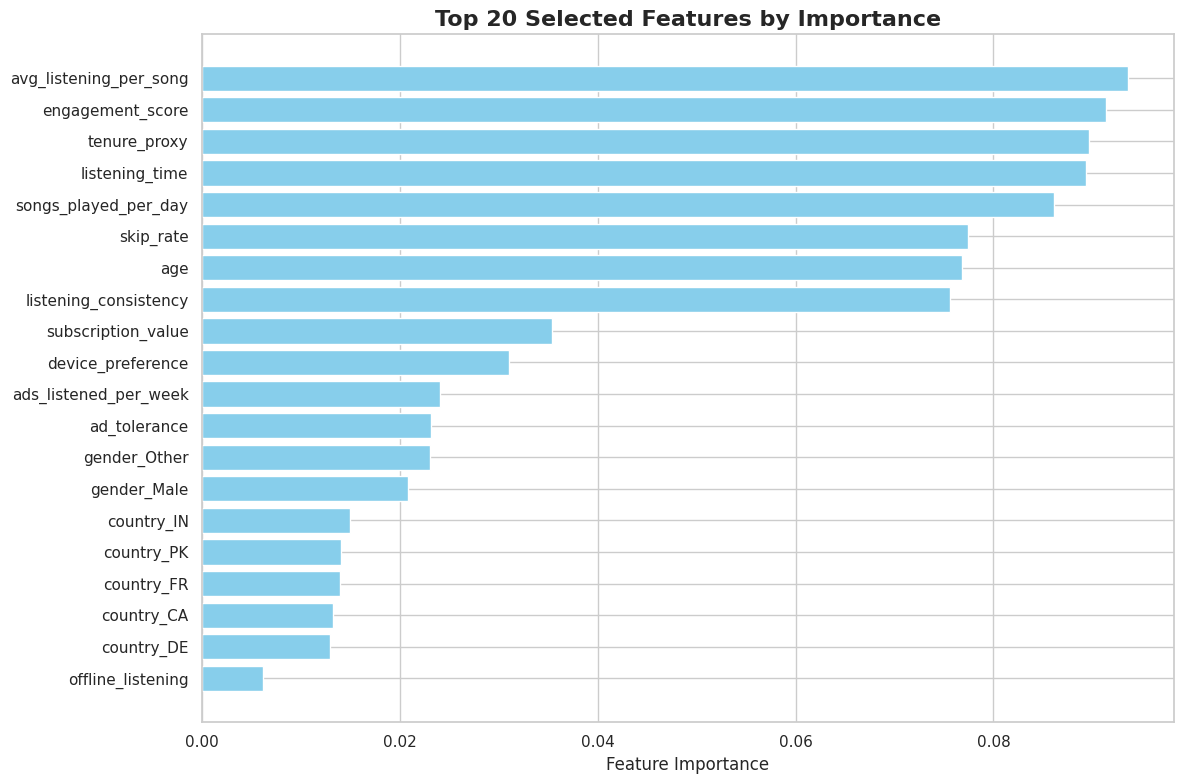

In [9]:
print("="*50)
print("FEATURE SELECTION")
print("="*50)

# Convert to numpy arrays for faster computation
X_train_np = X_train_final.values
X_test_np = X_test_df.values

print("Original number of features:", X_train_np.shape[1])

# Method 1: Correlation-based selection
print("\n CORRELATION-BASED FEATURE SELECTION:")
correlations = []
from scipy.stats import pearsonr

for i in range(X_train_np.shape[1]):
    col_data = X_train_np[:, i]
    try:
        col_data = col_data.astype(float)
    except ValueError:
        correlations.append(0)
        continue


    if np.std(col_data) > 1e-9 and np.std(y_train_final.values) > 1e-9:
        try:
            corr, _ = pearsonr(col_data, y_train_final.values)
            correlations.append(abs(corr))
        except ValueError:
            correlations.append(0)
    else:
        correlations.append(0)

# Top 30 features based on correlation
top_k = 30
selected_indices_corr = np.argsort(correlations)[-top_k:]
print(f"Selected top {top_k} features based on correlation")

# RandomForest for feature importance
print("\n RANDOM FOREST FEATURE IMPORTANCE:")
rf_for_selection = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_for_selection.fit(X_train_np, y_train_final)

# Get feature importances
importances = rf_for_selection.feature_importances_
selected_indices_rf = np.argsort(importances)[-top_k:]
print(f"Selected top {top_k} features based on Random Forest importance")

# SelectKBest with ANOVA F-value
selector = SelectKBest(score_func=f_classif, k=top_k)
selector.fit(X_train_np, y_train_final)
selected_indices_kbest = selector.get_support(indices=True)
print(f"Selected top {top_k} features based on ANOVA F-value")

# selection methods (union of all methods)
selected_indices_combined = np.union1d(selected_indices_corr, selected_indices_rf)
selected_indices_combined = np.union1d(selected_indices_combined, selected_indices_kbest)

print(f"\n FINAL FEATURE SELECTION:")
print(f"Combined selection: {len(selected_indices_combined)} features selected")
print(f"Reduction from {X_train_np.shape[1]} to {len(selected_indices_combined)} features")
print(f"Reduction percentage: {(1 - len(selected_indices_combined)/X_train_np.shape[1])*100:.1f}%")

# Apply final selection
X_train_selected = X_train_np[:, selected_indices_combined]
X_test_selected = X_test_np[:, selected_indices_combined]

# Get selected feature names
selected_feature_names = [all_feature_names[i] for i in selected_indices_combined]

print(f"\n✓ Training shape after selection: {X_train_selected.shape}")
print(f"✓ Test shape after selection: {X_test_selected.shape}")

# Visualize top 20 selected features
plt.figure(figsize=(12, 8))
top_features = selected_feature_names[:20]
top_importances = importances[selected_indices_combined][:20]
sorted_idx = np.argsort(top_importances)

plt.barh(range(len(sorted_idx)), top_importances[sorted_idx], color='skyblue')
plt.yticks(range(len(sorted_idx)), np.array(top_features)[sorted_idx])
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 20 Selected Features by Importance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
print("="*50)
print("INITIALIZING MODELS WITH IMPROVED HYPERPARAMETERS")
print("="*50)

class_weight_ratio = len(y_train_final[y_train_final==0]) / len(y_train_final[y_train_final==1])

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000,
        C=0.5,
        class_weight='balanced',
        solver='lbfgs',
        penalty='l2'
    ),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        max_depth=10,
        min_samples_split=15,
        min_samples_leaf=7,
        class_weight='balanced',
        max_features='sqrt'
    ),

    'Random Forest': RandomForestClassifier(
        random_state=42,
        n_estimators=300,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        n_jobs=-1,
        max_features='sqrt',
        bootstrap=True
    ),

    'XGBoost': XGBClassifier(
        random_state=42,
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=class_weight_ratio,
        reg_alpha=0.1,
        reg_lambda=1
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42,
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        min_samples_split=20,
        min_samples_leaf=10,
        subsample=0.8
    ),

    'Neural Network (MLP)': MLPClassifier(
        random_state=42,
        hidden_layer_sizes=(128, 64, 32),
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.2,
        alpha=0.001,
        learning_rate='adaptive',
        batch_size=256,
        solver='adam',
        activation='relu'
    )
}

print("✓ 6 models initialized successfully:")
for name, model in models.items():
    print(f"  - {name}")

print(f"\nClass weight ratio for imbalance: {class_weight_ratio:.2f}")

# Dictionary to store evaluation results
results_dict = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [],
    'ROC-AUC': [],
    'Train_Time': []
}

INITIALIZING MODELS WITH IMPROVED HYPERPARAMETERS
✓ 6 models initialized successfully:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - XGBoost
  - Gradient Boosting
  - Neural Network (MLP)

Class weight ratio for imbalance: 1.25


In [11]:
print("="*50)
print("DEFINING ENHANCED EVALUATION FUNCTION")
print("="*50)

def evaluate_model_comprehensive(model, X_train, y_train, X_test, y_test, model_name):
    """
    Comprehensive evaluation of a single model
    Returns a dictionary with all metrics
    """
    import time

    # Train the model and measure training time
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    # Probabilities for AUC-ROC
    if hasattr(model, "predict_proba"):
        try:
            y_pred_proba = model.predict_proba(X_test)[:, 1]
            y_pred_proba_train = model.predict_proba(X_train)[:, 1]
            roc_auc = roc_auc_score(y_test, y_pred_proba)
            roc_auc_train = roc_auc_score(y_train, y_pred_proba_train)
        except Exception as e:
            print(f"Warning: Could not calculate ROC-AUC for {model_name}: {e}")
            y_pred_proba = None
            roc_auc = None
            roc_auc_train = None
    else:
        y_pred_proba = None
        roc_auc = None
        roc_auc_train = None

    # Calculate metrics with zero_division parameter
    results = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Accuracy_Train': accuracy_score(y_train, y_pred_train),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Precision_Train': precision_score(y_train, y_pred_train, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'Recall_Train': recall_score(y_train, y_pred_train, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'F1-Score_Train': f1_score(y_train, y_pred_train, zero_division=0),
        'ROC-AUC': roc_auc,
        'ROC-AUC_Train': roc_auc_train,
        'Train_Time': train_time
    }

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    results['Confusion_Matrix'] = cm
    results['TP'] = cm[1, 1]
    results['FP'] = cm[0, 1]
    results['TN'] = cm[0, 0]
    results['FN'] = cm[1, 0]

    # Additional metrics
    results['Specificity'] = cm[0, 0] / (cm[0, 0] + cm[0, 1]) if (cm[0, 0] + cm[0, 1]) > 0 else 0

    return results, y_pred, y_pred_proba


DEFINING ENHANCED EVALUATION FUNCTION


In [12]:
print("="*60)
print("TRAINING AND EVALUATING ALL MODELS")
print("="*60)

# Store results
all_results = []
predictions = {}
models_trained = {}

print("Starting model training...\n")

for name, model in models.items():
    print(f"{'='*50}")
    print(f"Training {name}")
    print('='*50)

    try:
        # Evaluate model
        results, y_pred, y_pred_proba = evaluate_model_comprehensive(
            model, X_train_selected, y_train_final, X_test_selected, y_test, name
        )

        all_results.append(results)
        predictions[name] = {
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba
        }
        models_trained[name] = model

        # Display results
        print(f"✓ Training completed in {results['Train_Time']:.2f} seconds")
        print(f"  Test Accuracy:  {results['Accuracy']:.4f}")
        print(f"  Test Precision: {results['Precision']:.4f}")
        print(f"  Test Recall:    {results['Recall']:.4f}")
        print(f"  Test F1-Score:  {results['F1-Score']:.4f}")
        print(f"  Train F1-Score: {results['F1-Score_Train']:.4f}")
        if results['ROC-AUC'] is not None:
            print(f"  Test ROC-AUC:   {results['ROC-AUC']:.4f}")

        # Display confusion matrix
        print(f"\n  Confusion Matrix:")
        print(f"  [[{results['TN']:4d} {results['FP']:4d}]")
        print(f"   [{results['FN']:4d} {results['TP']:4d}]]")

        print()

    except Exception as e:
        print(f"✗ Error with {name}: {str(e)}")
        import traceback
        traceback.print_exc()
        continue

print("="*60)
print(" ALL MODELS TRAINED AND EVALUATED SUCCESSFULLY!")
print("="*60)

TRAINING AND EVALUATING ALL MODELS
Starting model training...

Training Logistic Regression
✓ Training completed in 0.05 seconds
  Test Accuracy:  0.5175
  Test Precision: 0.2699
  Test Recall:    0.5072
  Test F1-Score:  0.3523
  Train F1-Score: 0.5122
  Test ROC-AUC:   0.5003

  Confusion Matrix:
  [[ 618  568]
   [ 204  210]]

Training Decision Tree
✓ Training completed in 0.04 seconds
  Test Accuracy:  0.5019
  Test Precision: 0.2510
  Test Recall:    0.4662
  Test F1-Score:  0.3263
  Train F1-Score: 0.6203
  Test ROC-AUC:   0.4957

  Confusion Matrix:
  [[ 610  576]
   [ 221  193]]

Training Random Forest
✓ Training completed in 5.46 seconds
  Test Accuracy:  0.6581
  Test Precision: 0.2761
  Test Recall:    0.1981
  Test F1-Score:  0.2307
  Train F1-Score: 0.9728
  Test ROC-AUC:   0.5321

  Confusion Matrix:
  [[ 971  215]
   [ 332   82]]

Training XGBoost
✓ Training completed in 2.52 seconds
  Test Accuracy:  0.6306
  Test Precision: 0.2908
  Test Recall:    0.2971
  Test F1-Sco

In [13]:
print("="*60)
print("MODEL COMPARISON RESULTS")
print("="*60)

results_df = pd.DataFrame(all_results)

# Sort by F1-Score
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

# Display formatted results
print("\nPERFORMANCE METRICS (Sorted by F1-Score):")
display_cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Train_Time']
print(results_df[display_cols].round(4).to_string(index=False))

# Display overfitting analysis
print("\nOVERFITTING ANALYSIS (Train vs Test F1-Score):")
results_df['F1_Difference'] = results_df['F1-Score_Train'] - results_df['F1-Score']
overfitting_df = results_df[['Model', 'F1-Score_Train', 'F1-Score', 'F1_Difference']].round(4)
print(overfitting_df.to_string(index=False))

# Best performer
best_model_name = results_df.iloc[0]['Model']
best_f1 = results_df.iloc[0]['F1-Score']
best_auc = results_df.iloc[0]['ROC-AUC'] if 'ROC-AUC' in results_df.columns and pd.notna(results_df.iloc[0]['ROC-AUC']) else None

print(f"\nBEST PERFORMING MODEL: {best_model_name}")
print(f"   F1-Score: {best_f1:.4f}")
if best_auc:
    print(f"   ROC-AUC: {best_auc:.4f}")

# Save results to CSV
results_df.to_csv('model_performance_results_comprehensive.csv', index=False)

MODEL COMPARISON RESULTS

PERFORMANCE METRICS (Sorted by F1-Score):
               Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Train_Time
 Logistic Regression    0.5175     0.2699  0.5072    0.3523   0.5003      0.0535
       Decision Tree    0.5019     0.2510  0.4662    0.3263   0.4957      0.0405
             XGBoost    0.6306     0.2908  0.2971    0.2939   0.5336      2.5216
Neural Network (MLP)    0.5756     0.2437  0.3043    0.2707   0.5108      3.7475
       Random Forest    0.6581     0.2761  0.1981    0.2307   0.5321      5.4577
   Gradient Boosting    0.6762     0.2778  0.1570    0.2006   0.5213      9.1325

OVERFITTING ANALYSIS (Train vs Test F1-Score):
               Model  F1-Score_Train  F1-Score  F1_Difference
 Logistic Regression          0.5122    0.3523         0.1599
       Decision Tree          0.6203    0.3263         0.2940
             XGBoost          0.9966    0.2939         0.7027
Neural Network (MLP)          0.8321    0.2707         0.5615
       

VISUALIZING MODEL PERFORMANCE


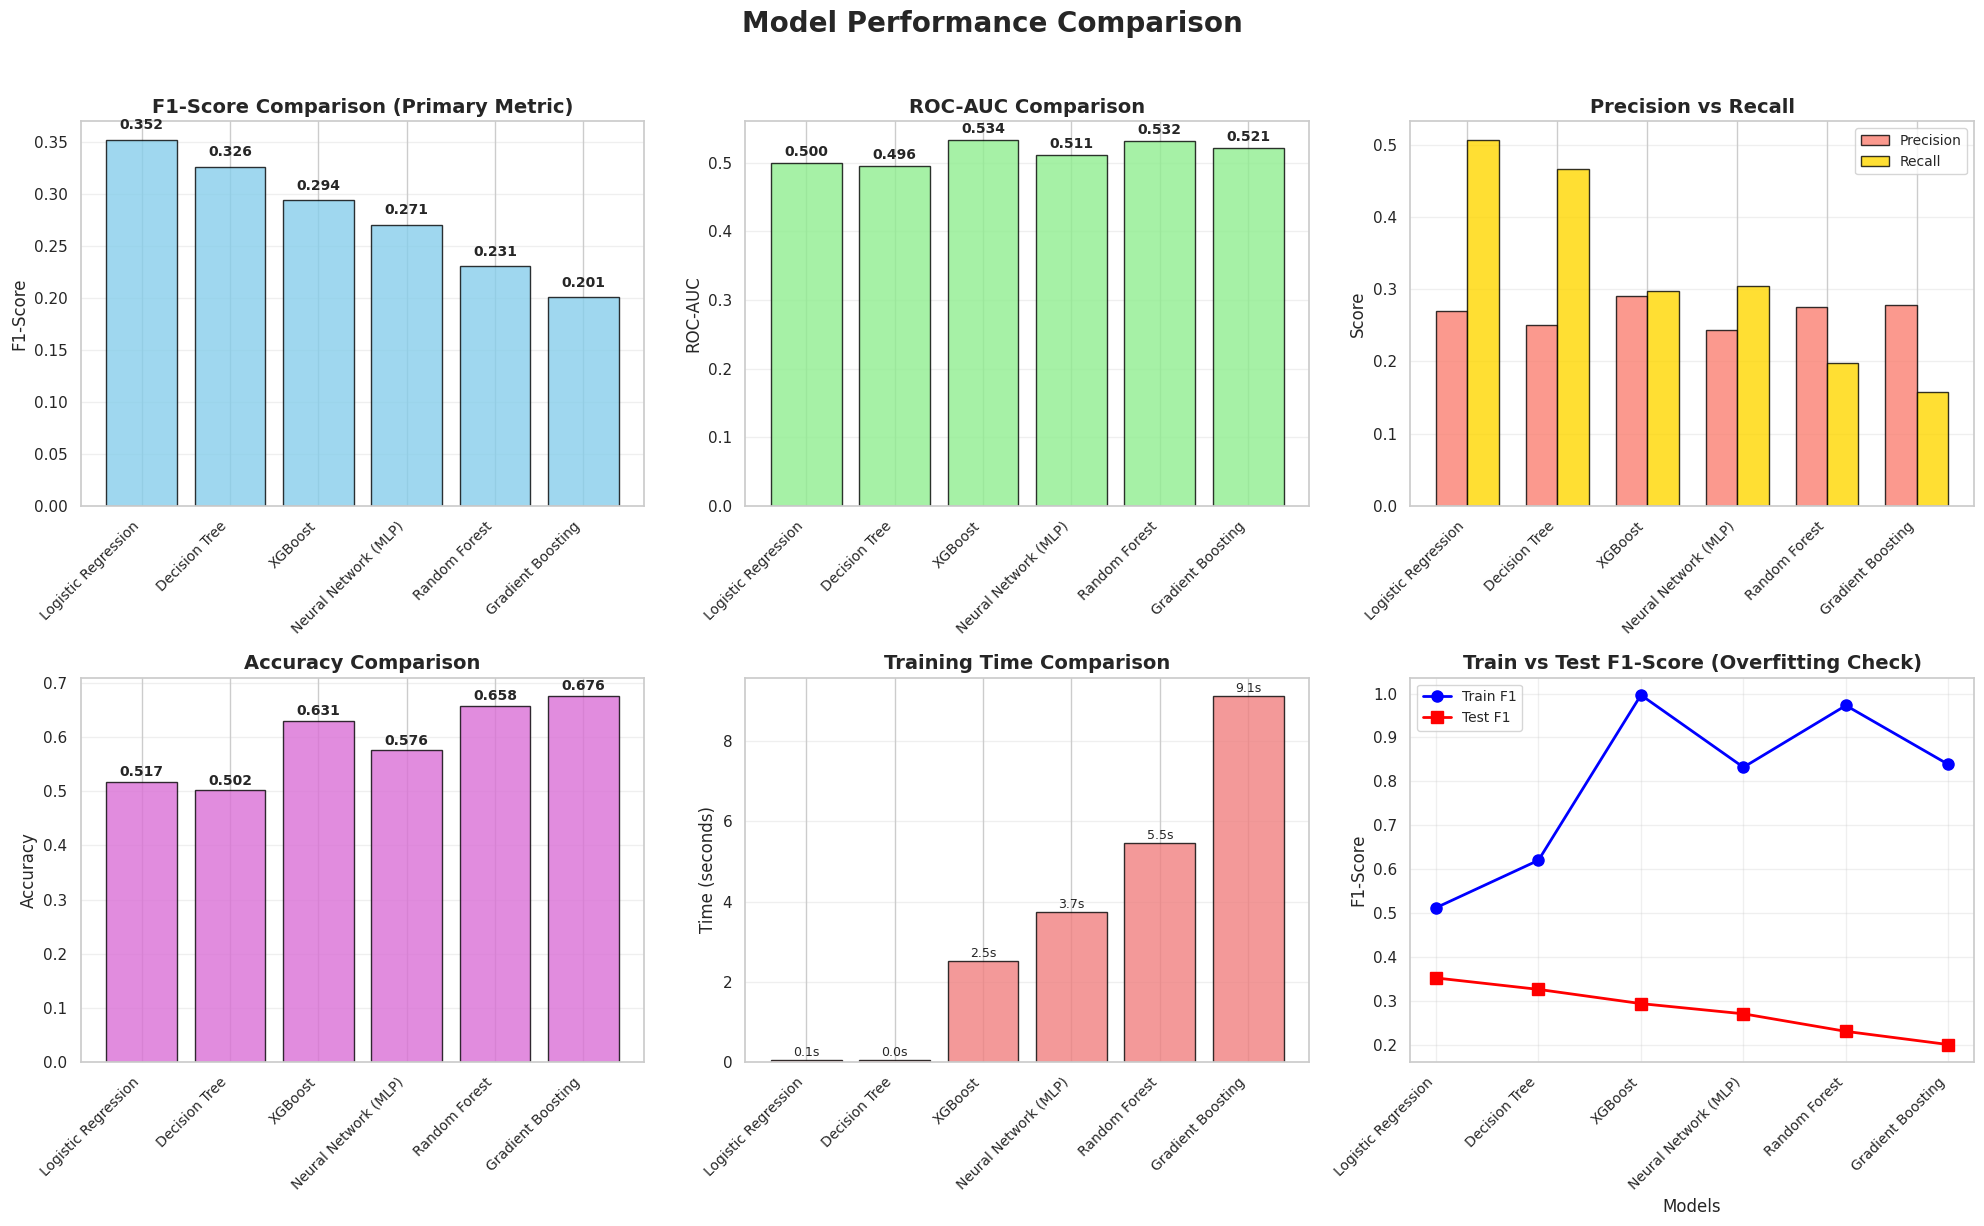

In [14]:
print("="*60)
print("VISUALIZING MODEL PERFORMANCE")
print("="*60)

# Create comparison plot
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Model Performance Comparison', fontsize=20, fontweight='bold', y=1.02)

# F1-Score Comparison
axes[0, 0].bar(range(len(results_df)), results_df['F1-Score'], color='skyblue', alpha=0.8, edgecolor='black')
axes[0, 0].set_title('F1-Score Comparison (Primary Metric)', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('F1-Score', fontsize=12)
axes[0, 0].set_xticks(range(len(results_df)))
axes[0, 0].set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=10)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(results_df['F1-Score']):
    axes[0, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

# ROC-AUC Comparison
if 'ROC-AUC' in results_df.columns and results_df['ROC-AUC'].notna().any():
    axes[0, 1].bar(range(len(results_df)), results_df['ROC-AUC'], color='lightgreen', alpha=0.8, edgecolor='black')
    axes[0, 1].set_title('ROC-AUC Comparison', fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel('ROC-AUC', fontsize=12)
    axes[0, 1].set_xticks(range(len(results_df)))
    axes[0, 1].set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=10)
    axes[0, 1].grid(True, alpha=0.3, axis='y')

    for i, v in enumerate(results_df['ROC-AUC']):
        if pd.notna(v):
            axes[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

# Precision-Recall Comparison
width = 0.35
x = np.arange(len(results_df))
axes[0, 2].bar(x - width/2, results_df['Precision'], width, label='Precision', color='salmon', alpha=0.8, edgecolor='black')
axes[0, 2].bar(x + width/2, results_df['Recall'], width, label='Recall', color='gold', alpha=0.8, edgecolor='black')
axes[0, 2].set_title('Precision vs Recall', fontsize=14, fontweight='bold')
axes[0, 2].set_ylabel('Score', fontsize=12)
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=10)
axes[0, 2].legend(fontsize=10)
axes[0, 2].grid(True, alpha=0.3, axis='y')

# Accuracy Comparison
axes[1, 0].bar(range(len(results_df)), results_df['Accuracy'], color='orchid', alpha=0.8, edgecolor='black')
axes[1, 0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Accuracy', fontsize=12)
axes[1, 0].set_xticks(range(len(results_df)))
axes[1, 0].set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=10)
axes[1, 0].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(results_df['Accuracy']):
    axes[1, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

# Training Time Comparison
axes[1, 1].bar(range(len(results_df)), results_df['Train_Time'], color='lightcoral', alpha=0.8, edgecolor='black')
axes[1, 1].set_title('Training Time Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Time (seconds)', fontsize=12)
axes[1, 1].set_xticks(range(len(results_df)))
axes[1, 1].set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(results_df['Train_Time']):
    axes[1, 1].text(i, v + 0.1, f'{v:.1f}s', ha='center', fontsize=9)

# Overfitting Analysis (Train vs Test F1)
x = np.arange(len(results_df))
axes[1, 2].plot(x, results_df['F1-Score_Train'], 'o-', label='Train F1', color='blue', linewidth=2, markersize=8)
axes[1, 2].plot(x, results_df['F1-Score'], 's-', label='Test F1', color='red', linewidth=2, markersize=8)
axes[1, 2].set_title('Train vs Test F1-Score (Overfitting Check)', fontsize=14, fontweight='bold')
axes[1, 2].set_ylabel('F1-Score', fontsize=12)
axes[1, 2].set_xlabel('Models', fontsize=12)
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=10)
axes[1, 2].legend(fontsize=10)
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


ROC CURVES AND PRECISION-RECALL CURVES


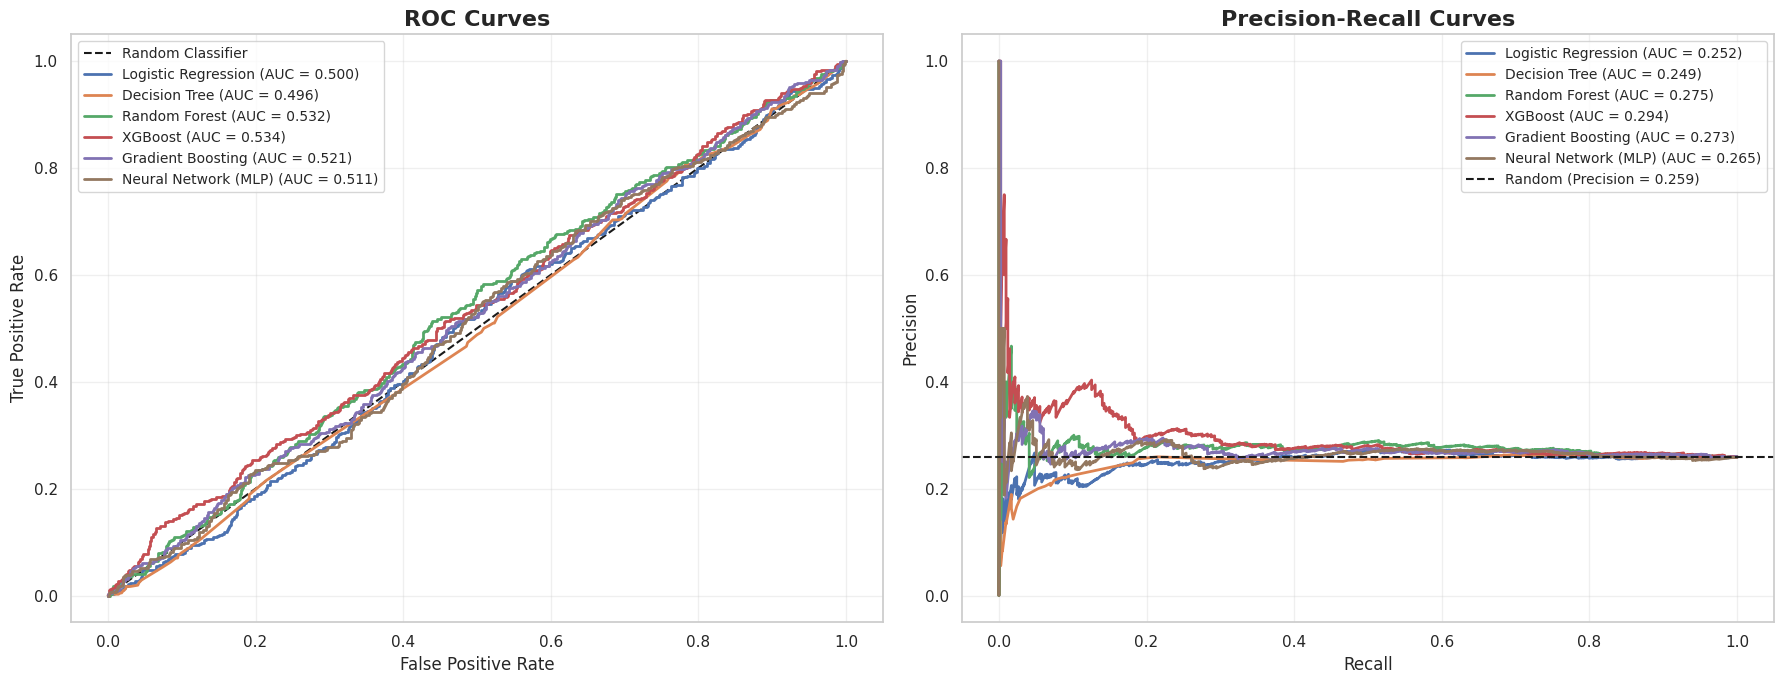

In [15]:
print("="*60)
print("ROC CURVES AND PRECISION-RECALL CURVES")
print("="*60)

# Plot ROC curves for all models that have predict_proba
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# ROC Curve
ax1.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
for name, preds in predictions.items():
    if preds['y_pred_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, preds['y_pred_proba'])
        roc_auc = auc(fpr, tpr)
        ax1.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2)

ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curves', fontsize=16, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Precision-Recall Curve
for name, preds in predictions.items():
    if preds['y_pred_proba'] is not None:
        precision, recall, _ = precision_recall_curve(y_test, preds['y_pred_proba'])
        pr_auc = auc(recall, precision)
        baseline = len(y_test[y_test==1]) / len(y_test)  # Random classifier precision
        ax2.plot(recall, precision, label=f'{name} (AUC = {pr_auc:.3f})', linewidth=2)

ax2.axhline(y=baseline, color='k', linestyle='--', label=f'Random (Precision = {baseline:.3f})')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curves', fontsize=16, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

FEATURE IMPORTANCE ANALYSIS
Analyzing feature importance for best model: Logistic Regression


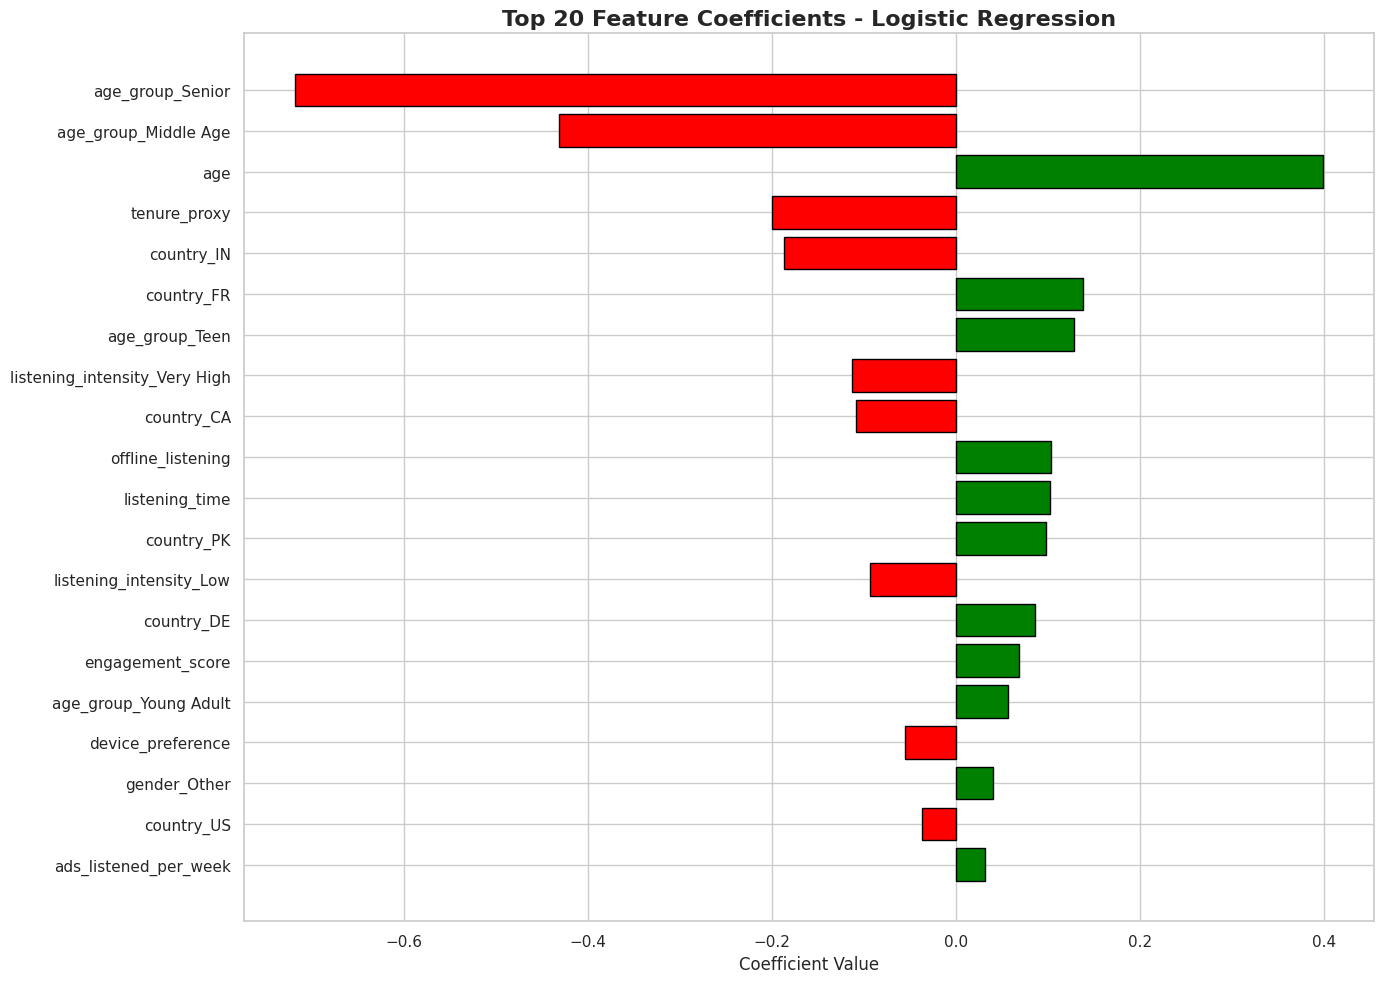

\n TOP 10 MOST INFLUENTIAL FEATURES:
   1. age_group_Senior: - 0.7180
   2. age_group_Middle Age: - 0.4318
   3. age: + 0.3983
   4. tenure_proxy: - 0.2006
   5. country_IN: - 0.1875
   6. country_FR: + 0.1378
   7. age_group_Teen: + 0.1285
   8. listening_intensity_Very High: - 0.1132
   9. country_CA: - 0.1092
  10. offline_listening: + 0.1033


In [16]:
print("="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get the best model
best_model_name = results_df.iloc[0]['Model']
best_model = models_trained[best_model_name]

print(f"Analyzing feature importance for best model: {best_model_name}")

if hasattr(best_model, 'feature_importances_'):
    # Tree-based models
    importances = best_model.feature_importances_

    # Get indices sorted by importance
    indices = np.argsort(importances)[::-1]

    # Plot top 20 features
    plt.figure(figsize=(14, 10))
    top_n = min(20, len(selected_feature_names))
    plt.barh(range(top_n), importances[indices[:top_n]][::-1], color='skyblue', edgecolor='black')
    plt.yticks(range(top_n), [selected_feature_names[i] for i in indices[:top_n]][::-1])
    plt.xlabel('Feature Importance', fontsize=12)
    plt.title(f'Top {top_n} Feature Importances - {best_model_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Display top 10 features
    print(f"\\n TOP 10 MOST IMPORTANT FEATURES:")
    for i in range(min(10, len(indices))):
        print(f"  {i+1:2d}. {selected_feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

elif hasattr(best_model, 'coef_'):
    # Linear models
    coef = best_model.coef_[0]

    indices = np.argsort(np.abs(coef))[::-1]

    # Plot top 20 features
    plt.figure(figsize=(14, 10))
    top_n = min(20, len(selected_feature_names))
    colors = ['red' if coef[i] < 0 else 'green' for i in indices[:top_n]]
    plt.barh(range(top_n), coef[indices[:top_n]][::-1], color=colors[::-1], edgecolor='black')
    plt.yticks(range(top_n), [selected_feature_names[i] for i in indices[:top_n]][::-1])
    plt.xlabel('Coefficient Value', fontsize=12)
    plt.title(f'Top {top_n} Feature Coefficients - {best_model_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Display top 10 features
    print(f"\\n TOP 10 MOST INFLUENTIAL FEATURES:")
    for i in range(min(10, len(indices))):
        sign = '-' if coef[indices[i]] < 0 else '+'
        print(f"  {i+1:2d}. {selected_feature_names[indices[i]]}: {sign} {abs(coef[indices[i]]):.4f}")
else:
    print(f"Feature importance not available for {best_model_name}")

In [17]:
print("="*60)
print("HYPERPARAMETER TUNING FOR BEST MODEL")
print("="*60)

print(f"Best model identified: {best_model_name}")

# Define hyperparameter grids for different models
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 15, 20, None],
        'min_samples_split': [5, 10, 15],
        'min_samples_leaf': [2, 5, 10],
        'max_features': ['sqrt', 'log2']
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0]
    },
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'min_samples_split': [10, 20, 30]
    }
}

if best_model_name in param_grids:

    tuning_size = min(3000, len(X_train_selected))
    tuning_indices = np.random.choice(len(X_train_selected), size=tuning_size, replace=False)
    X_tuning = X_train_selected[tuning_indices]
    y_tuning = y_train_final.iloc[tuning_indices]

    # Create base model
    if best_model_name == 'Random Forest':
        base_model = RandomForestClassifier(random_state=42, class_weight='balanced_subsample', n_jobs=-1)
    elif best_model_name == 'XGBoost':
        base_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
    elif best_model_name == 'Logistic Regression':
        base_model = LogisticRegression(random_state=42, max_iter=1000)
    elif best_model_name == 'Gradient Boosting':
        base_model = GradientBoostingClassifier(random_state=42)
    else:
        base_model = models[best_model_name]

    # Perform Randomized Search
    random_search = RandomizedSearchCV(
        base_model,
        param_grids[best_model_name],
        n_iter=20,
        cv=3,
        scoring='f1',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    random_search.fit(X_tuning, y_tuning)

    print(f"\n Best parameters found:")
    for param, value in random_search.best_params_.items():
        print(f"  {param}: {value}")

    print(f"Best F1-Score: {random_search.best_score_:.4f}")

    # Train final model with best parameters on full data
    print(f"\n Training final model with best parameters on full data...")
    final_model = random_search.best_estimator_
    final_model.fit(X_train_selected, y_train_final)

    # Evaluate final model
    final_results, final_y_pred, final_y_pred_proba = evaluate_model_comprehensive(
        final_model, X_train_selected, y_train_final, X_test_selected, y_test, f"{best_model_name} (Tuned)"
    )

    print(f"\n FINAL TUNED MODEL PERFORMANCE:")
    print(f"  Test F1-Score:  {final_results['F1-Score']:.4f}")
    print(f"  Test Accuracy:  {final_results['Accuracy']:.4f}")
    print(f"  Test Precision: {final_results['Precision']:.4f}")
    print(f"  Test Recall:    {final_results['Recall']:.4f}")
    if final_results['ROC-AUC'] is not None:
        print(f"  Test ROC-AUC:   {final_results['ROC-AUC']:.4f}")

    # Compare with original
    original_f1 = results_df[results_df['Model'] == best_model_name]['F1-Score'].values[0]
    improvement = ((final_results['F1-Score'] - original_f1) / original_f1) * 100
    print(f"\n Improvement over original: {improvement:+.1f}%")

    # Save the tuned model
    import joblib
    joblib.dump(final_model, f'best_model_{best_model_name.lower().replace(" ", "_")}_tuned.pkl')
    print(f"\n✓ Tuned model saved to 'best_model_{best_model_name.lower().replace(" ", "_")}_tuned.pkl'")
else:
    print(f"\n No parameter grid defined for {best_model_name}. Skipping hyperparameter tuning.")

HYPERPARAMETER TUNING FOR BEST MODEL
Best model identified: Logistic Regression
Fitting 3 folds for each of 20 candidates, totalling 60 fits

 Best parameters found:
  solver: saga
  penalty: l1
  C: 10
Best F1-Score: 0.2906

 Training final model with best parameters on full data...

 FINAL TUNED MODEL PERFORMANCE:
  Test F1-Score:  0.1318
  Test Accuracy:  0.6706
  Test Precision: 0.2073
  Test Recall:    0.0966
  Test ROC-AUC:   0.4995

 Improvement over original: -62.6%

✓ Tuned model saved to 'best_model_logistic_regression_tuned.pkl'


In [18]:
print("="*60)
print("SAVING FINAL RESULTS AND SUMMARY")
print("="*60)

summary_data = {
    'Dataset_Information': {
        'Total_Records': len(df),
        'Total_Features_Original': 11,
        'Total_Features_After_Engineering': df.shape[1] - 1,
        'Churn_Rate': f"{y.mean():.2%}",
        'Class_Distribution': f"Active: {len(y[y==0])} ({len(y[y==0])/len(y):.1%}), "
                             f"Churned: {len(y[y==1])} ({len(y[y==1])/len(y):.1%})"
    },
    'Preprocessing_Details': {
        'Outlier_Handling': 'Capped at 1st and 99th percentiles',
        'Feature_Engineering': f"Created {len(new_features)} new features",
        'Feature_Selection': f"Reduced from {X_train_np.shape[1]} to {len(selected_indices_combined)} features",
        'Class_Imbalance': 'Handled using SMOTE + RandomUnderSampler'
    },
    'Best_Model': {
        'Model_Name': best_model_name,
        'F1_Score': f"{best_f1:.4f}",
        'ROC_AUC': f"{best_auc:.4f}" if best_auc else 'N/A',
        'Accuracy': f"{results_df.iloc[0]['Accuracy']:.4f}",
        'Precision': f"{results_df.iloc[0]['Precision']:.4f}",
        'Recall': f"{results_df.iloc[0]['Recall']:.4f}"
    },
    'Performance_Comparison': results_df[['Model', 'F1-Score', 'ROC-AUC', 'Accuracy', 'Train_Time']].to_dict('records')
}

# Save summary to JSON
import json
with open('churn_prediction_summary.json', 'w') as f:
    json.dump(summary_data, f, indent=4)

print("Results summary saved to 'churn_prediction_summary.json'")

# Save all models
import joblib
for name, model in models_trained.items():
    filename = f"model_{name.lower().replace(' ', '_').replace('(', '').replace(')', '')}.pkl"
    joblib.dump(model, filename)
    print(f"Model saved: {filename}")

# Save predictions
predictions_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions[best_model_name]['y_pred']
})
if predictions[best_model_name]['y_pred_proba'] is not None:
    predictions_df['Probability'] = predictions[best_model_name]['y_pred_proba']

predictions_df.to_csv('final_predictions.csv', index=False)
print("Predictions saved to 'final_predictions.csv'")



SAVING FINAL RESULTS AND SUMMARY
Results summary saved to 'churn_prediction_summary.json'
Model saved: model_logistic_regression.pkl
Model saved: model_decision_tree.pkl
Model saved: model_random_forest.pkl
Model saved: model_xgboost.pkl
Model saved: model_gradient_boosting.pkl
Model saved: model_neural_network_mlp.pkl
Predictions saved to 'final_predictions.csv'
